# 03 · Multi-tier model training

| Tier | Task | Unit | Models |
|---|---|---|---|
| 1 | Gram Positive vs Negative | well image (pooled per isolate) | XGBoost, SVM-RBF, FT-Transformer |
| 2 | Growth vs No Growth | well | XGBoost, SVM-RBF, FT-Transformer |
| 3 | MIC call (+ DSI, S/I/R) | isolate × drug series | derived from each model's Tier 2 probabilities |

* **Tuning:** RandomizedSearchCV for XGBoost (30 candidates) and RBF-SVM (20 candidates), both with **5-fold GroupKFold by isolate**.
* **Overfitting guard:** the winner is the best validation AUC among candidates with a train-validation gap ≤ 0.03.
* **Threshold:** Youden's J on out-of-fold training predictions.
* **Saved:** each tier model is a full Pipeline (`models/tier*_*.joblib`), and each classifier family is also saved as a 3-tier cascade (`models/multitier_*.joblib`).

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/gram-id-ast-ml


In [2]:
# Rebuild the isolate-grouped splits if they are missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
# Train everything once if the saved cascades are missing (about 6 minutes)
if not all(cfg.cascade_file(m).exists() for m in cfg.MODEL_NAMES):
    from src.features import build_features as bf
    from src.models import train_model as tm
    bf.run(); tm.run(); plt.close("all")
elif not cfg.SELECTED_FEATURES_FILE.exists():
    from src.features import build_features as bf
    bf.run(); plt.close("all")

from src.models import train_model as tm
from src.utils import load_json

## 1. Search spaces

In [3]:
for label, space in [("XGBoost", tm.XGB_SPACE), ("SVM-RBF", tm.SVM_SPACE)]:
    print(label)
    for k, v in space.items():
        dist = getattr(v, "dist", None)
        print(f"   {k.replace('clf__', ''):18s}", dist.name if dist else v, getattr(v, "args", ""))
print("FT-Transformer:", tm.TRANSFORMER_PARAMS)

XGBoost
   n_estimators       randint (100, 500)
   max_depth          randint (2, 6)
   learning_rate      loguniform (0.02, 0.2)
   subsample          uniform (0.6, 0.4)
   colsample_bytree   uniform (0.5, 0.5)
   min_child_weight   randint (1, 30)
   gamma              uniform (0, 3)
   reg_lambda         loguniform (0.01, 20)
   reg_alpha          loguniform (0.001, 5)
SVM-RBF
   C                  loguniform (0.1, 100.0)
   gamma              loguniform (0.001, 1)
   class_weight       [None, 'balanced'] 
FT-Transformer: {'d_token': 24, 'n_heads': 4, 'n_layers': 2, 'ff_mult': 2, 'dropout': 0.2, 'lr': 0.002, 'weight_decay': 0.0001, 'batch_size': 512, 'max_epochs': 40, 'patience': 6, 'random_state': 42}


## 2. Train or load
Set `RETRAIN = True` to retrain from scratch (about 6 minutes on 2 CPU cores).

In [4]:
RETRAIN = False
if RETRAIN:
    tm.run(); plt.close("all")
cascades = tm.load_cascades()
meta = load_json(cfg.MODEL_METADATA_FILE)
cascades

{'XGBoost': MultiTierClassifier(XGBoost: tier1 9 features, tier2 9 features),
 'SVM-RBF': MultiTierClassifier(SVM-RBF: tier1 9 features, tier2 9 features),
 'Transformer': MultiTierClassifier(Transformer: tier1 9 features, tier2 9 features)}

In [5]:
rows = []
for m, tiers in meta["models"].items():
    for tier in cfg.TIERS:
        t = tiers[tier]
        rows.append({"Model": m, "Tier": tier, "OOF CV AUC": t["oof_cv_auc"], "threshold": t["decision_threshold"],
                     "train s": t["train_seconds"], "n features": len(t["features"])})
pd.DataFrame(rows).round(4)

,Model,Tier,OOF CV AUC,threshold,train s,n features
0,XGBoost,tier1_gram,0.9969,0.7330,16.5,9
1,XGBoost,tier2_growth,0.9991,0.4856,12.9,9
2,SVM-RBF,tier1_gram,0.9962,0.5127,15.1,9
3,SVM-RBF,tier2_growth,0.9989,0.5586,15.7,9
4,Transformer,tier1_gram,0.9948,0.5791,98.5,9
5,Transformer,tier2_growth,0.9982,0.4398,151.3,9


In [6]:
for m in cfg.MODEL_NAMES:
    for tier in cfg.TIERS:
        print(f"{m:11s} {tier:13s}", {k: (round(v, 4) if isinstance(v, float) else v)
                                     for k, v in meta["models"][m][tier]["best_params"].items()})

XGBoost     tier1_gram    {'colsample_bytree': 0.8313, 'gamma': 0.9351, 'learning_rate': 0.0662, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 409, 'reg_alpha': 0.0013, 'reg_lambda': 6.0312, 'subsample': 0.7799}
XGBoost     tier2_growth  {'colsample_bytree': 0.6669, 'gamma': 0.4286, 'learning_rate': 0.0895, 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 443, 'reg_alpha': 1.2, 'reg_lambda': 0.0502, 'subsample': 0.6727}
SVM-RBF     tier1_gram    {'C': 65.4121, 'class_weight': 'balanced', 'gamma': 0.0035, 'probability': True}
SVM-RBF     tier2_growth  {'C': 22.674, 'class_weight': None, 'gamma': 0.014, 'probability': True}
Transformer tier1_gram    {'d_token': 24, 'n_heads': 4, 'n_layers': 2, 'ff_mult': 2, 'dropout': 0.2, 'lr': 0.002, 'weight_decay': 0.0001, 'batch_size': 512, 'max_epochs': 40, 'patience': 6, 'random_state': 42}
Transformer tier2_growth  {'d_token': 24, 'n_heads': 4, 'n_layers': 2, 'ff_mult': 2, 'dropout': 0.2, 'lr': 0.002, 'weight_decay': 0.0001, 'batch_

## 3. Hyperparameter search results

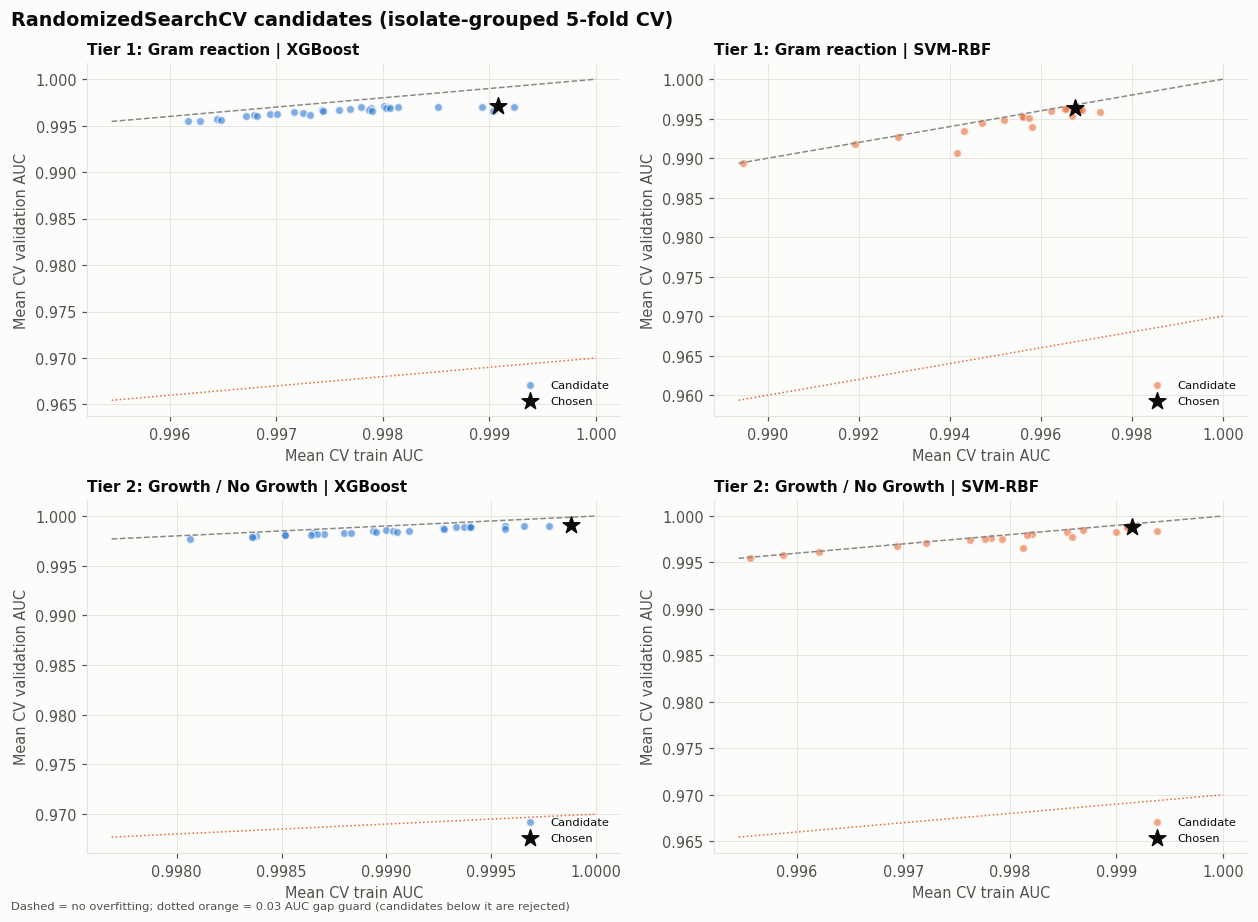

In [7]:
search = {(t, n): pd.read_csv(cfg.TABLES_DIR / f"search_{t}_{n.lower().replace('-', '_')}.csv")
          for t in cfg.TIERS for n in ["XGBoost", "SVM-RBF"]}
tm.plot_search(search);

In [8]:
display(search[("tier2_growth", "XGBoost")].head(5).round(4))
display(search[("tier2_growth", "SVM-RBF")].head(5).round(4))

,param_clf__colsample_bytree,param_clf__gamma,param_clf__learning_rate,param_clf__max_depth,param_clf__min_child_weight,param_clf__n_estimators,param_clf__reg_alpha,param_clf__reg_lambda,param_clf__subsample,mean_train_score,mean_test_score,std_test_score,gap,chosen
0,0.6669,0.4286,0.0895,2,2,443,1.2000,0.0502,0.6727,0.9999,0.9991,0.0001,0.0008,True
1,0.6839,0.7956,0.0351,3,6,464,0.0632,9.7962,0.7738,0.9996,0.9990,0.0001,0.0006,False
2,0.8313,0.9351,0.0662,3,4,409,0.0013,6.0312,0.7799,0.9998,0.9990,0.0002,0.0008,False
3,0.7469,0.5365,0.0465,5,7,294,0.2707,0.7516,0.6375,0.9997,0.9990,0.0001,0.0007,False
4,0.5025,0.4824,0.0708,3,3,307,4.7695,0.0381,0.6072,0.9994,0.9990,0.0001,0.0004,False


,param_clf__C,param_clf__class_weight,param_clf__gamma,mean_train_score,mean_test_score,std_test_score,gap,chosen
0,22.6740,NaN,0.0140,0.9991,0.9988,0.0003,0.0003,True
1,9.7178,balanced,0.0189,0.9991,0.9988,0.0003,0.0003,False
2,6.6471,NaN,0.0225,0.9991,0.9988,0.0003,0.0003,False
3,65.4121,balanced,0.0035,0.9987,0.9985,0.0003,0.0002,False
4,83.4193,NaN,0.0233,0.9994,0.9984,0.0005,0.0010,False


## 4. FT-Transformer training curves

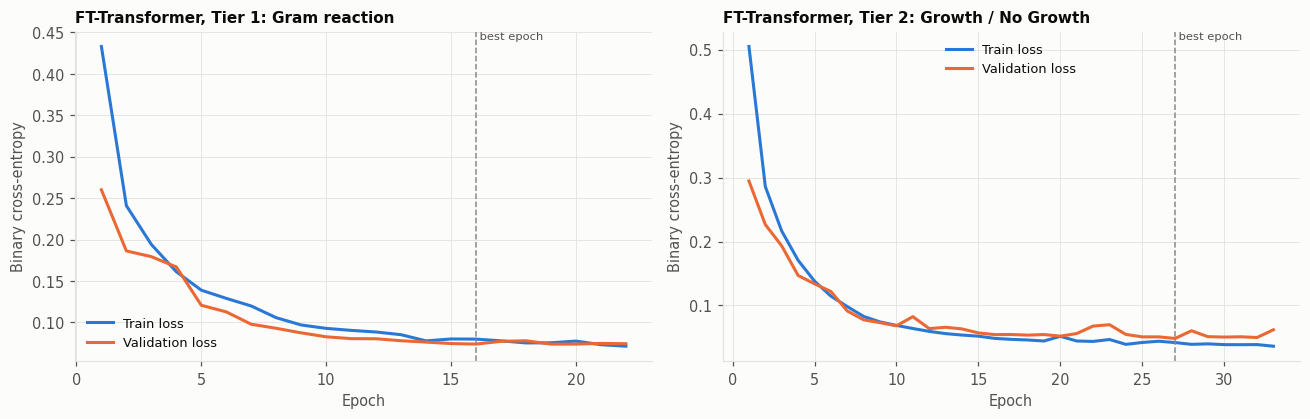

In [9]:
tm.plot_transformer_history({t: (cascades["Transformer"].tier1_model if t == "tier1_gram"
                                 else cascades["Transformer"].tier2_model).named_steps["clf"] for t in cfg.TIERS});

## 5. Using a saved cascade

In [10]:
from src.data.make_dataset import load_split
test = load_split("test")
one_isolate = test[test[cfg.T1_TARGET] == cfg.T1_POS][cfg.ISOLATE_ID].iloc[0]
out = cascades["XGBoost"].predict(test[test[cfg.ISOLATE_ID] == one_isolate])
display(out["gram"]); display(out["wells"].head(9)); display(out["mic"])

,Isolate_ID,P_Gram_Positive,n_well_images,Gram_Call
0,GP0061,0.980987,36,Gram Positive


,Well_ID,Isolate_ID,Antimicrobial,Concentration_ug_mL,Well_DSI,P_Growth,Growth_Call
103,GP0061-DAP-01,GP0061,Daptomycin,0.06,1,0.9996,Growth
104,GP0061-DAP-02,GP0061,Daptomycin,0.12,2,0.9997,Growth
105,GP0061-DAP-03,GP0061,Daptomycin,0.25,3,0.9995,Growth
106,GP0061-DAP-04,GP0061,Daptomycin,0.50,4,0.0011,No Growth
107,GP0061-DAP-05,GP0061,Daptomycin,1.00,5,0.0002,No Growth
108,GP0061-DAP-06,GP0061,Daptomycin,2.00,6,0.0005,No Growth
109,GP0061-DAP-07,GP0061,Daptomycin,4.00,7,0.0000,No Growth
110,GP0061-DAP-08,GP0061,Daptomycin,8.00,8,0.0000,No Growth
111,GP0061-CEF-01,GP0061,Ceftriaxone,0.12,1,0.9999,Growth


,Isolate_ID,Organism,Antimicrobial,pred_dsi,pred_mic,pred_cat
0,GP0061,Staphylococcus aureus,Daptomycin,4,0.5,S
1,GP0061,Staphylococcus aureus,Ceftriaxone,10,64,R
2,GP0061,Staphylococcus aureus,Meropenem,10,>16,R
3,GP0061,Staphylococcus aureus,Ampicillin,10,>32,R
